In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

%matplotlib inline

In [4]:
df = pd.read_csv("dataset/Crop_recommendation.csv")
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


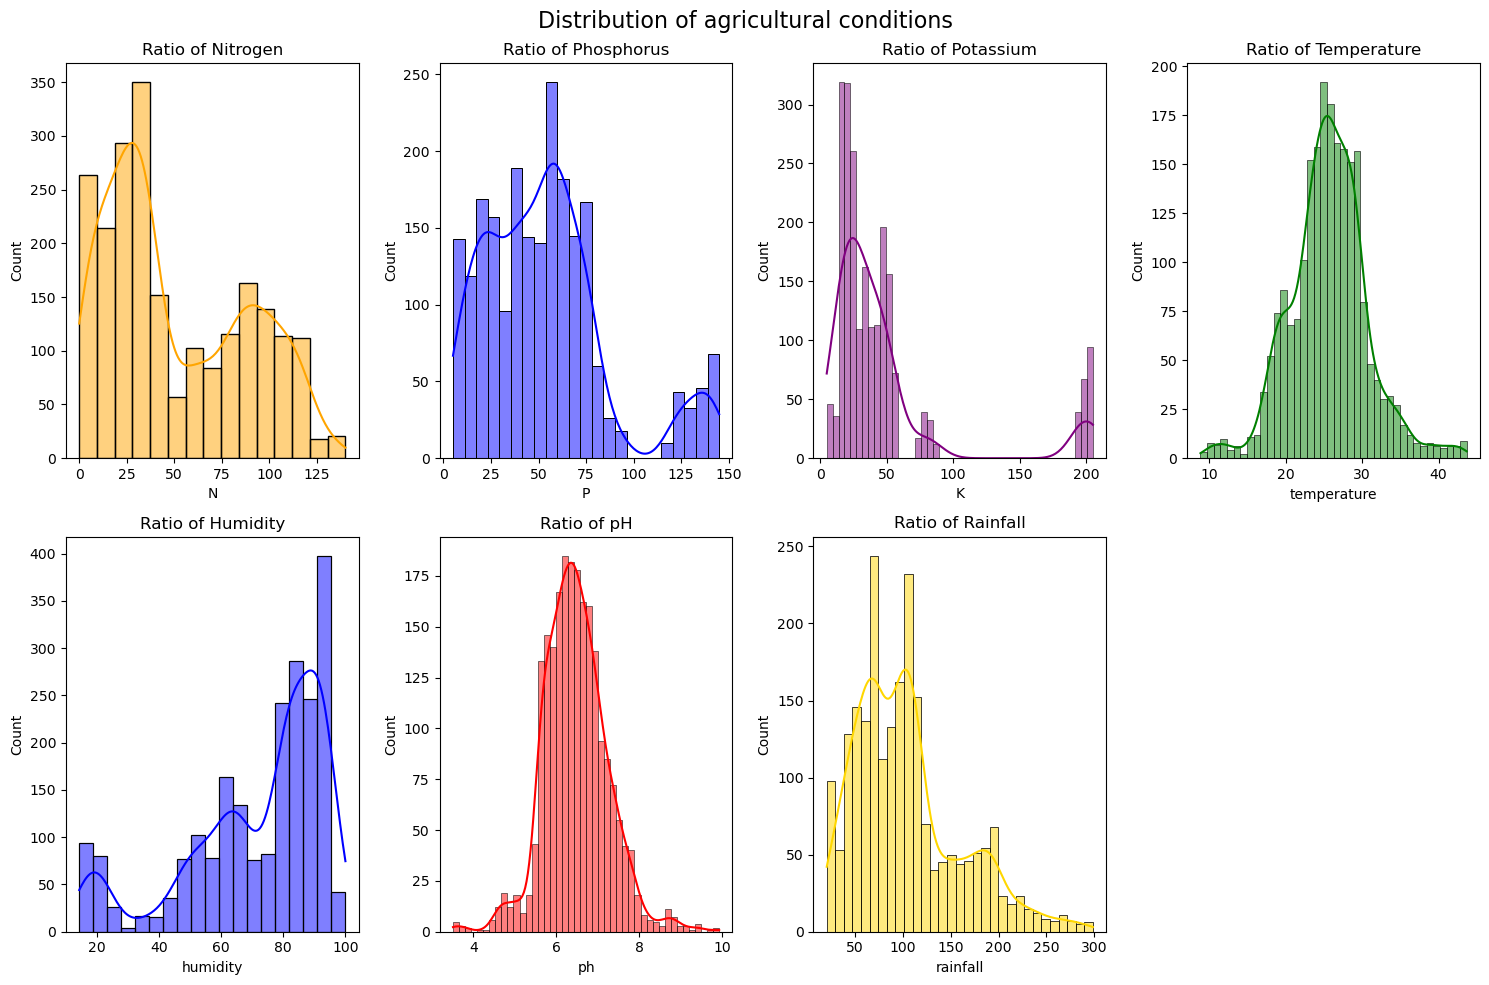

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,10))

plt.subplot(2,4,1)
sns.histplot(df['N'], kde=True, color='orange')
plt.title("Ratio of Nitrogen")

plt.subplot(2,4,2)
sns.histplot(df['P'], kde=True, color='blue')
plt.title("Ratio of Phosphorus")

plt.subplot(2,4,3)
sns.histplot(df['K'], kde=True, color='purple')
plt.title("Ratio of Potassium")

plt.subplot(2,4,4)
sns.histplot(df['temperature'], kde=True, color='green')
plt.title("Ratio of Temperature")

plt.subplot(2,4,5)
sns.histplot(df['humidity'], kde=True, color='blue')
plt.title("Ratio of Humidity")

plt.subplot(2,4,6)
sns.histplot(df['ph'], kde=True, color='red')
plt.title("Ratio of pH")

plt.subplot(2,4,7)
sns.histplot(df['rainfall'], kde=True, color='gold')
plt.title("Ratio of Rainfall")

plt.suptitle("Distribution of agricultural conditions", fontsize=16)
plt.tight_layout()
plt.show()

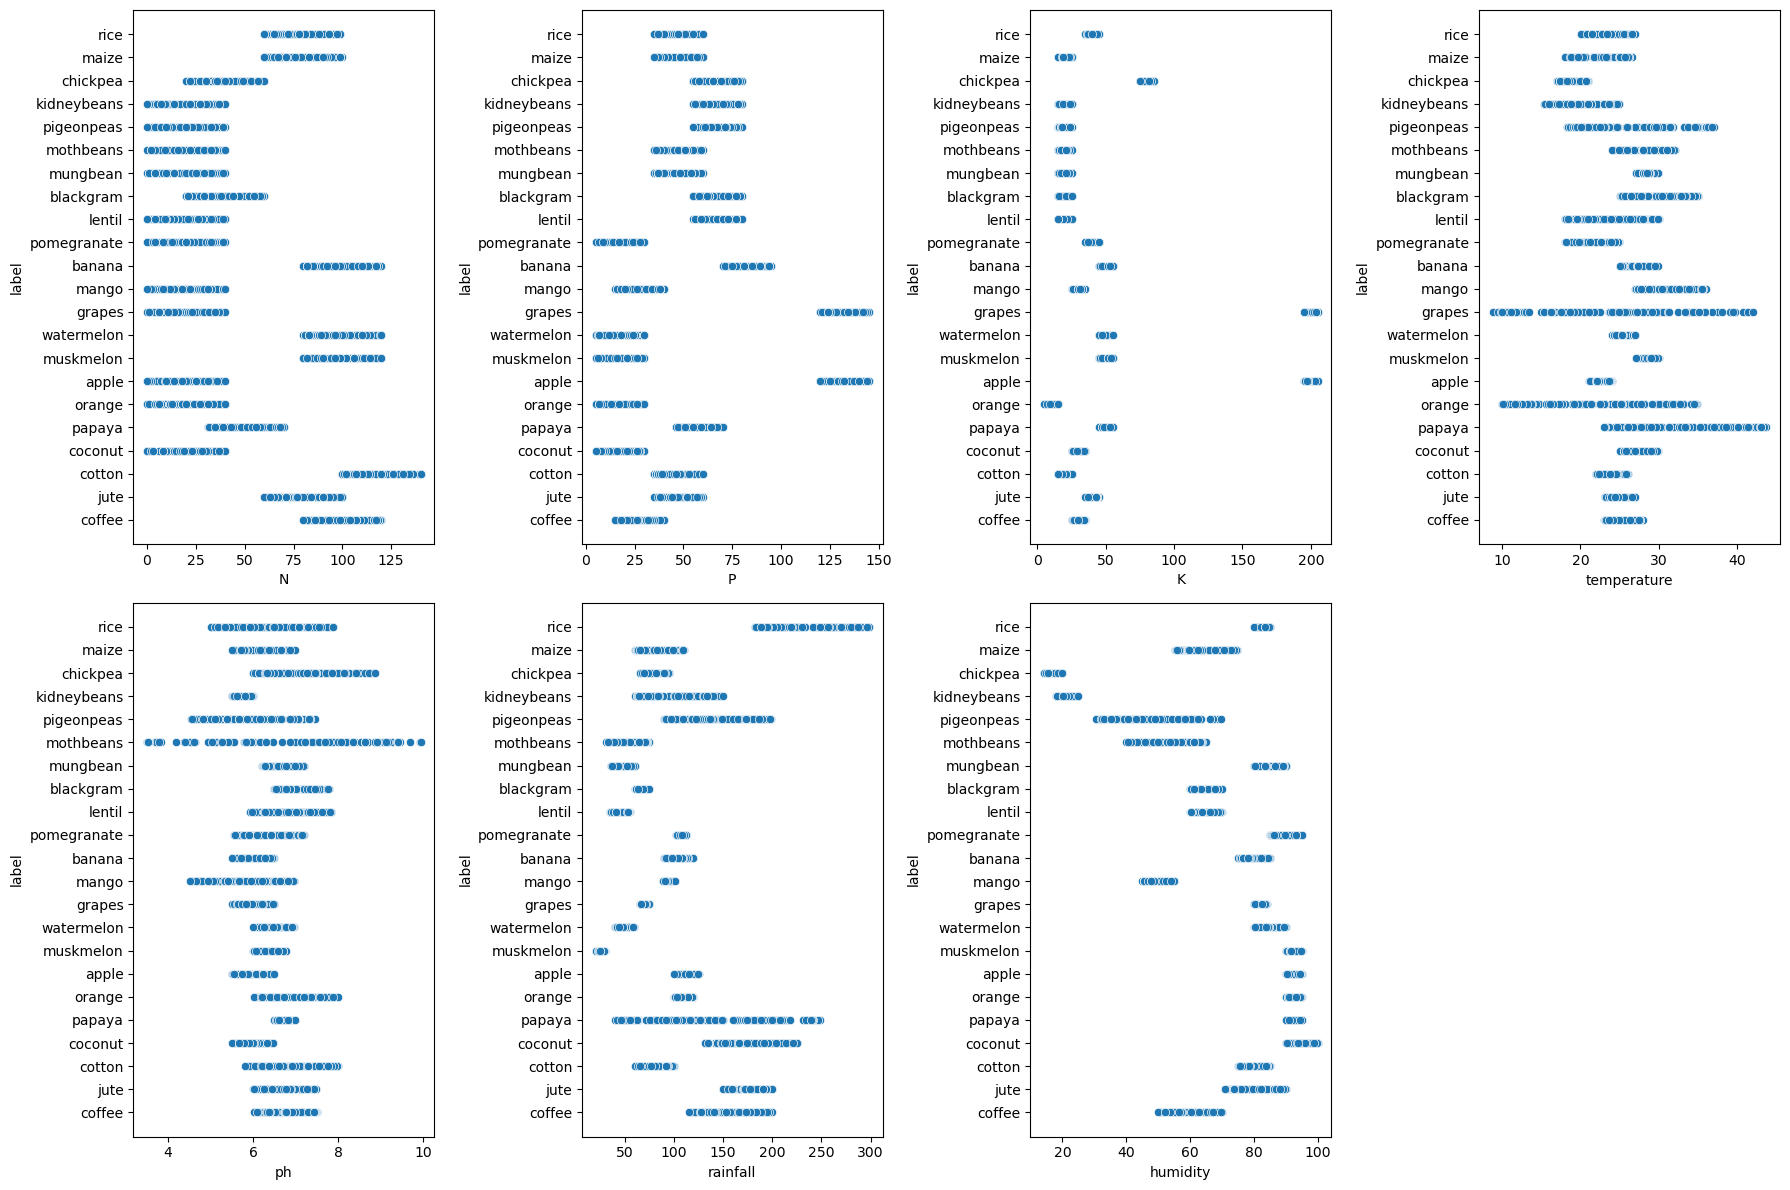

In [9]:
plt.figure(figsize=(18,12))

plt.subplot(2,4,1)
sns.scatterplot(x=df['N'], y=df['label'])

plt.subplot(2,4,2)
sns.scatterplot(x=df['P'], y=df['label'])

plt.subplot(2,4,3)
sns.scatterplot(x=df['K'], y=df['label'])

plt.subplot(2,4,4)
sns.scatterplot(x=df['temperature'], y=df['label'])

plt.subplot(2,4,5)
sns.scatterplot(x=df['ph'], y=df['label'])

plt.subplot(2,4,6)
sns.scatterplot(x=df['rainfall'], y=df['label'])

plt.subplot(2,4,7)
sns.scatterplot(x=df['humidity'], y=df['label'])

plt.tight_layout()
plt.show()

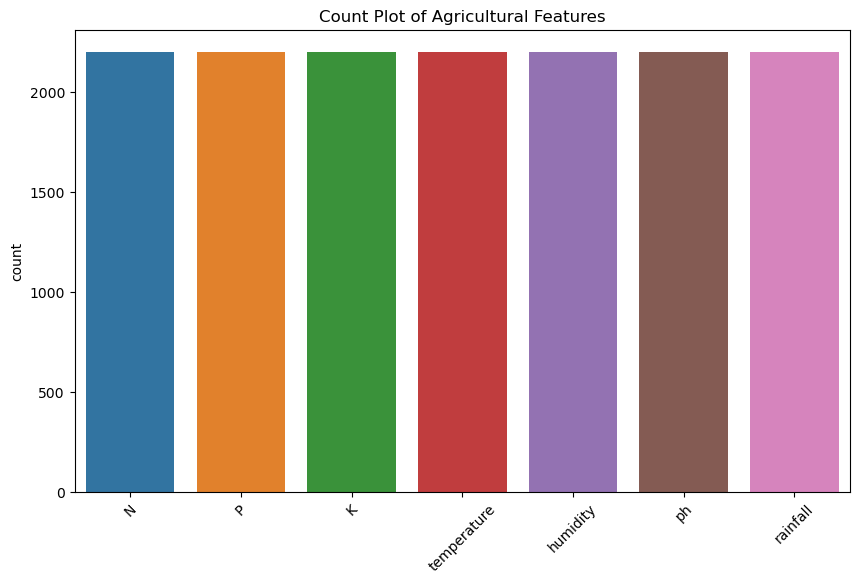

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.countplot(data=df)
plt.xticks(rotation=45)
plt.title("Count Plot of Agricultural Features")
plt.show()

In [13]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [15]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [17]:
df.shape

(2200, 8)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


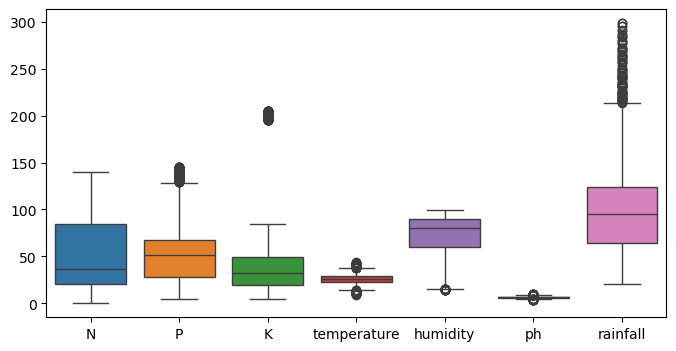

In [21]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df)
plt.show()

In [23]:
Q1 = df['P'].quantile(0.25)
Q3 = df['P'].quantile(0.75)
IQR = Q3 - Q1

filter = (df['P'] >= Q1 - 1.5 * IQR) & (df['P'] <= Q3 + 1.5 * IQR)

df = df.loc[filter]

In [25]:
summer_crops = df[(df['temperature'] > 30) & (df['humidity'] > 50)]['label'].unique()
winter_crops = df[(df['temperature'] < 20) & (df['humidity'] > 30)]['label'].unique()
rainy_crops  = df[(df['rainfall'] > 200) & (df['humidity'] > 50)]['label'].unique()

print("Summer crops:", summer_crops)
print("Winter crops:", winter_crops)
print("Rainy crops:", rainy_crops)

Summer crops: ['pigeonpeas' 'mothbeans' 'blackgram' 'mango' 'grapes' 'orange' 'papaya']
Winter crops: ['maize' 'pigeonpeas' 'lentil' 'pomegranate' 'grapes' 'orange']
Rainy crops: ['rice' 'papaya' 'coconut']


In [46]:
y = df['label']
x = df.drop(['label'], axis=1)

print("Shape of x", x.shape)
print("Shape of x=y", y.shape)

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=0
)

print("The shape of x train", x_train.shape)
print("The shape of x test", x_test.shape)
print("The shape of y train", y_train.shape)
print("The shape of y test", y_test.shape)

Shape of x (2062, 7)
Shape of x=y (2062,)
The shape of x train (1649, 7)
The shape of x test (413, 7)
The shape of y train (1649,)
The shape of y test (413,)


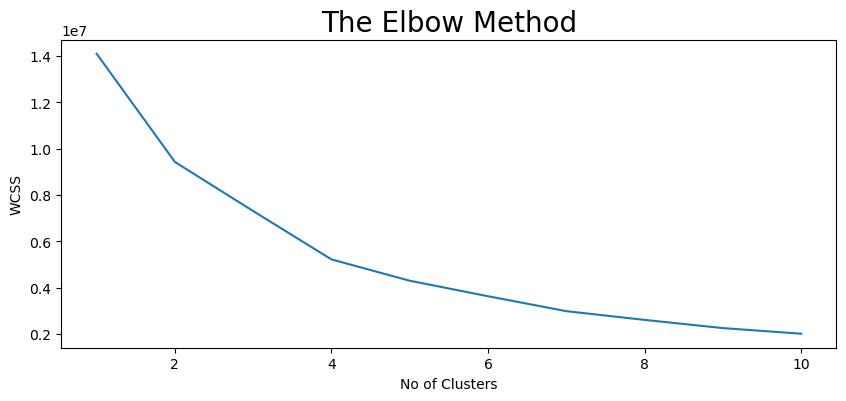

In [33]:
from sklearn.cluster import KMeans
x = df.drop('label', axis=1)
plt.rcParams['figure.figsize'] = (10,4)

wcss = []

for i in range(1,11):
    km = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    km.fit(x)
    wcss.append(km.inertia_)

plt.plot(range(1,11), wcss)
plt.title('The Elbow Method', fontsize=20)
plt.xlabel('No of Clusters')
plt.ylabel('WCSS')
plt.show()

In [38]:
km = KMeans(n_clusters=4, init='k-means++', max_iter=300, n_init=10, random_state=0)

y_means = km.fit_predict(x)

a = df['label']

y_means = pd.DataFrame(y_means)

z = pd.concat([y_means, a], axis=1)

z = z.rename(columns={0:'Cluster'})
print("Let's check the results after applying K-Means Clustering\n")

print("Crops in First Cluster:")
print(z[z['Cluster']==0]['label'].unique())

print("\nCrops in Second Cluster:")
print(z[z['Cluster']==1]['label'].unique())

print("\nCrops in Third Cluster:")
print(z[z['Cluster']==2]['label'].unique())

print("\nCrops in Fourth Cluster:")
print(z[z['Cluster']==3]['label'].unique())

Let's check the results after applying K-Means Clustering

Crops in First Cluster:
['maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans' 'mungbean'
 'blackgram' 'lentil' 'pomegranate' 'mango' 'muskmelon' 'apple' nan
 'orange' 'papaya']

Crops in Second Cluster:
['rice' 'pigeonpeas' 'apple' nan 'orange' 'papaya' 'coconut' 'cotton'
 'jute']

Crops in Third Cluster:
['maize' 'banana' nan 'grapes' 'watermelon' 'muskmelon' 'orange' 'papaya'
 'coconut' 'cotton' 'jute']

Crops in Fourth Cluster:
[nan 'grapes' 'muskmelon']


In [50]:
from sklearn.model_selection import train_test_split

X = df.drop('label', axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [52]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

model

/home/rguktrkvalley/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [54]:
from sklearn.metrics import classification_report
cr = classification_report(y_test,y_pred)
print(cr)

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00         9
      banana       1.00      1.00      1.00        14
   blackgram       0.84      0.80      0.82        20
    chickpea       1.00      1.00      1.00        22
     coconut       0.95      1.00      0.98        21
      coffee       1.00      1.00      1.00        27
      cotton       0.86      0.95      0.90        20
      grapes       1.00      1.00      1.00         6
        jute       0.86      1.00      0.93        19
 kidneybeans       1.00      0.96      0.98        27
      lentil       0.86      0.92      0.89        13
       maize       0.94      0.85      0.89        20
       mango       0.95      1.00      0.98        20
   mothbeans       0.90      0.79      0.84        24
    mungbean       0.89      1.00      0.94        16
   muskmelon       1.00      1.00      1.00        18
      orange       1.00      1.00      1.00        19
      papaya       0.93    

In [62]:
prediction = model.predict(np.array([[105,35,40,25,64,7,160]]))
print("The suggested crop for given climatic condition is:", prediction)

The suggested crop for given climatic condition is: ['coffee']


/home/rguktrkvalley/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [65]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))